# TOM Conference Code
## Exploration and Exploitation in a Distributed Representation of Organizational Knowledge

## Fast and Slow Learner individuals analysis

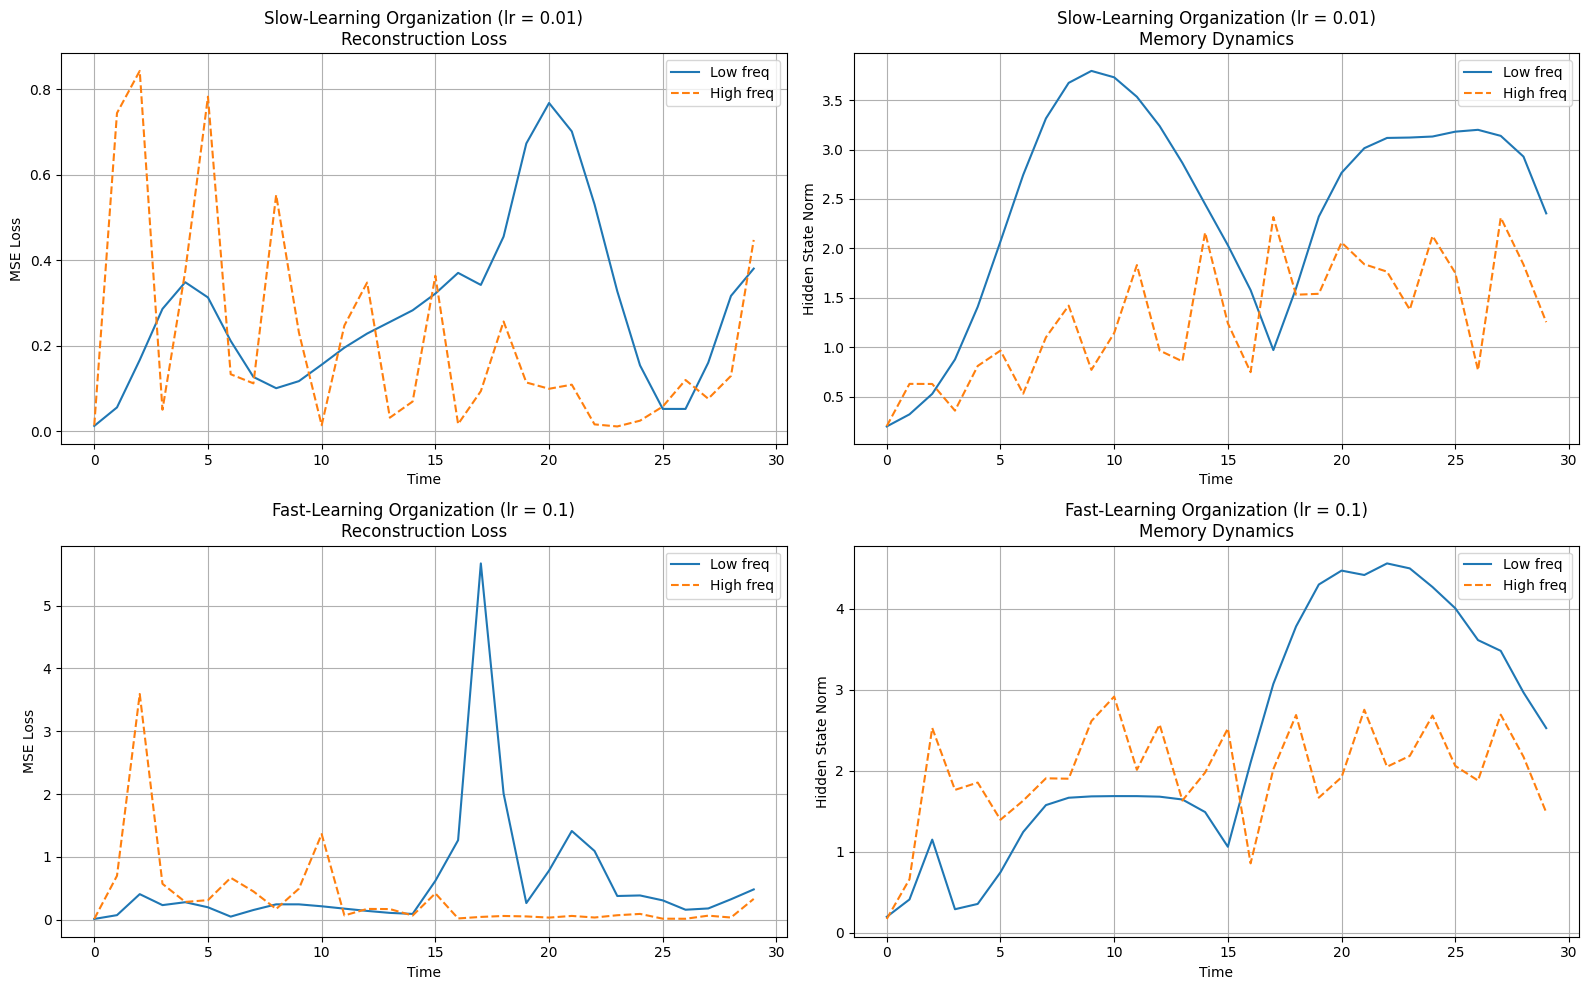

In [7]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# =========================================================
# Configuration
# =========================================================
T = 30        # time steps
D = 30           # input dimension
H = 30           # hidden neurons (= organizational members)
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

# =========================================================
# Environment generator
# =========================================================
def generate_sinusoid(T, D, freq):
    t = np.linspace(0, 2 * np.pi * freq, T)
    signal = np.sin(t)
    return np.tile(signal[:, None], (1, D)).astype(np.float32)

# =========================================================
# Organization = single LSTM
# =========================================================
class OrganizationLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim)
        self.linear = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        out = self.linear(out)
        return out, hidden

# =========================================================
# Run organization in an environment
# =========================================================
def run_environment(freq, lr):
    model = OrganizationLSTM(D, H)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    x_np = generate_sinusoid(T, D, freq)
    x = torch.from_numpy(x_np).unsqueeze(1)

    losses = []
    hidden_norms = []

    hidden = None
    for t in range(T):
        optimizer.zero_grad()

        out, hidden = model(x[t:t+1], hidden)

        # ---- critical fix: detach memory from graph ----
        hidden = (hidden[0].detach(), hidden[1].detach())

        loss = loss_fn(out.squeeze(0), x[t])
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        hidden_norms.append(hidden[0].norm().item())

    return losses, hidden_norms

# =========================================================
# Experiments
# =========================================================
low_freq = 1
high_freq = 10

# Slow-learning organization
slow_lr = 0.01
slow_low_loss, slow_low_mem = run_environment(low_freq, slow_lr)
slow_high_loss, slow_high_mem = run_environment(high_freq, slow_lr)

# Fast-learning organization
fast_lr = 0.1
fast_low_loss, fast_low_mem = run_environment(low_freq, fast_lr)
fast_high_loss, fast_high_mem = run_environment(high_freq, fast_lr)

# =========================================================
# Visualization
# =========================================================
plt.figure(figsize=(16, 10))

# --- Loss: slow learner ---
plt.subplot(2, 2, 1)
plt.plot(slow_low_loss, label="Low freq")
plt.plot(slow_high_loss, '--', label="High freq")
plt.title("Slow-Learning Organization (lr = 0.01)\nReconstruction Loss")
plt.xlabel("Time")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

# --- Memory: slow learner ---
plt.subplot(2, 2, 2)
plt.plot(slow_low_mem, label="Low freq")
plt.plot(slow_high_mem, '--', label="High freq")
plt.title("Slow-Learning Organization (lr = 0.01)\nMemory Dynamics")
plt.xlabel("Time")
plt.ylabel("Hidden State Norm")
plt.legend()
plt.grid(True)

# --- Loss: fast learner ---
plt.subplot(2, 2, 3)
plt.plot(fast_low_loss, label="Low freq")
plt.plot(fast_high_loss, '--', label="High freq")
plt.title("Fast-Learning Organization (lr = 0.1)\nReconstruction Loss")
plt.xlabel("Time")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

# --- Memory: fast learner ---
plt.subplot(2, 2, 4)
plt.plot(fast_low_mem, label="Low freq")
plt.plot(fast_high_mem, '--', label="High freq")
plt.title("Fast-Learning Organization (lr = 0.1)\nMemory Dynamics")
plt.xlabel("Time")
plt.ylabel("Hidden State Norm")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Testing Mutiple scenarios with different sinusoidal frquencies and amplitudes and random values

Running: 1_March
Running: 2_Random
Running: 3_Slow_Sine
Running: 4_Fast_Sine
Running: 5_Slow_Reg→Chaos
Running: 6_Fast_Reg→Chaos
Running: 7_Slow_Reg→Chaos→Reg
Running: 8_Fast_Reg→Chaos→Reg


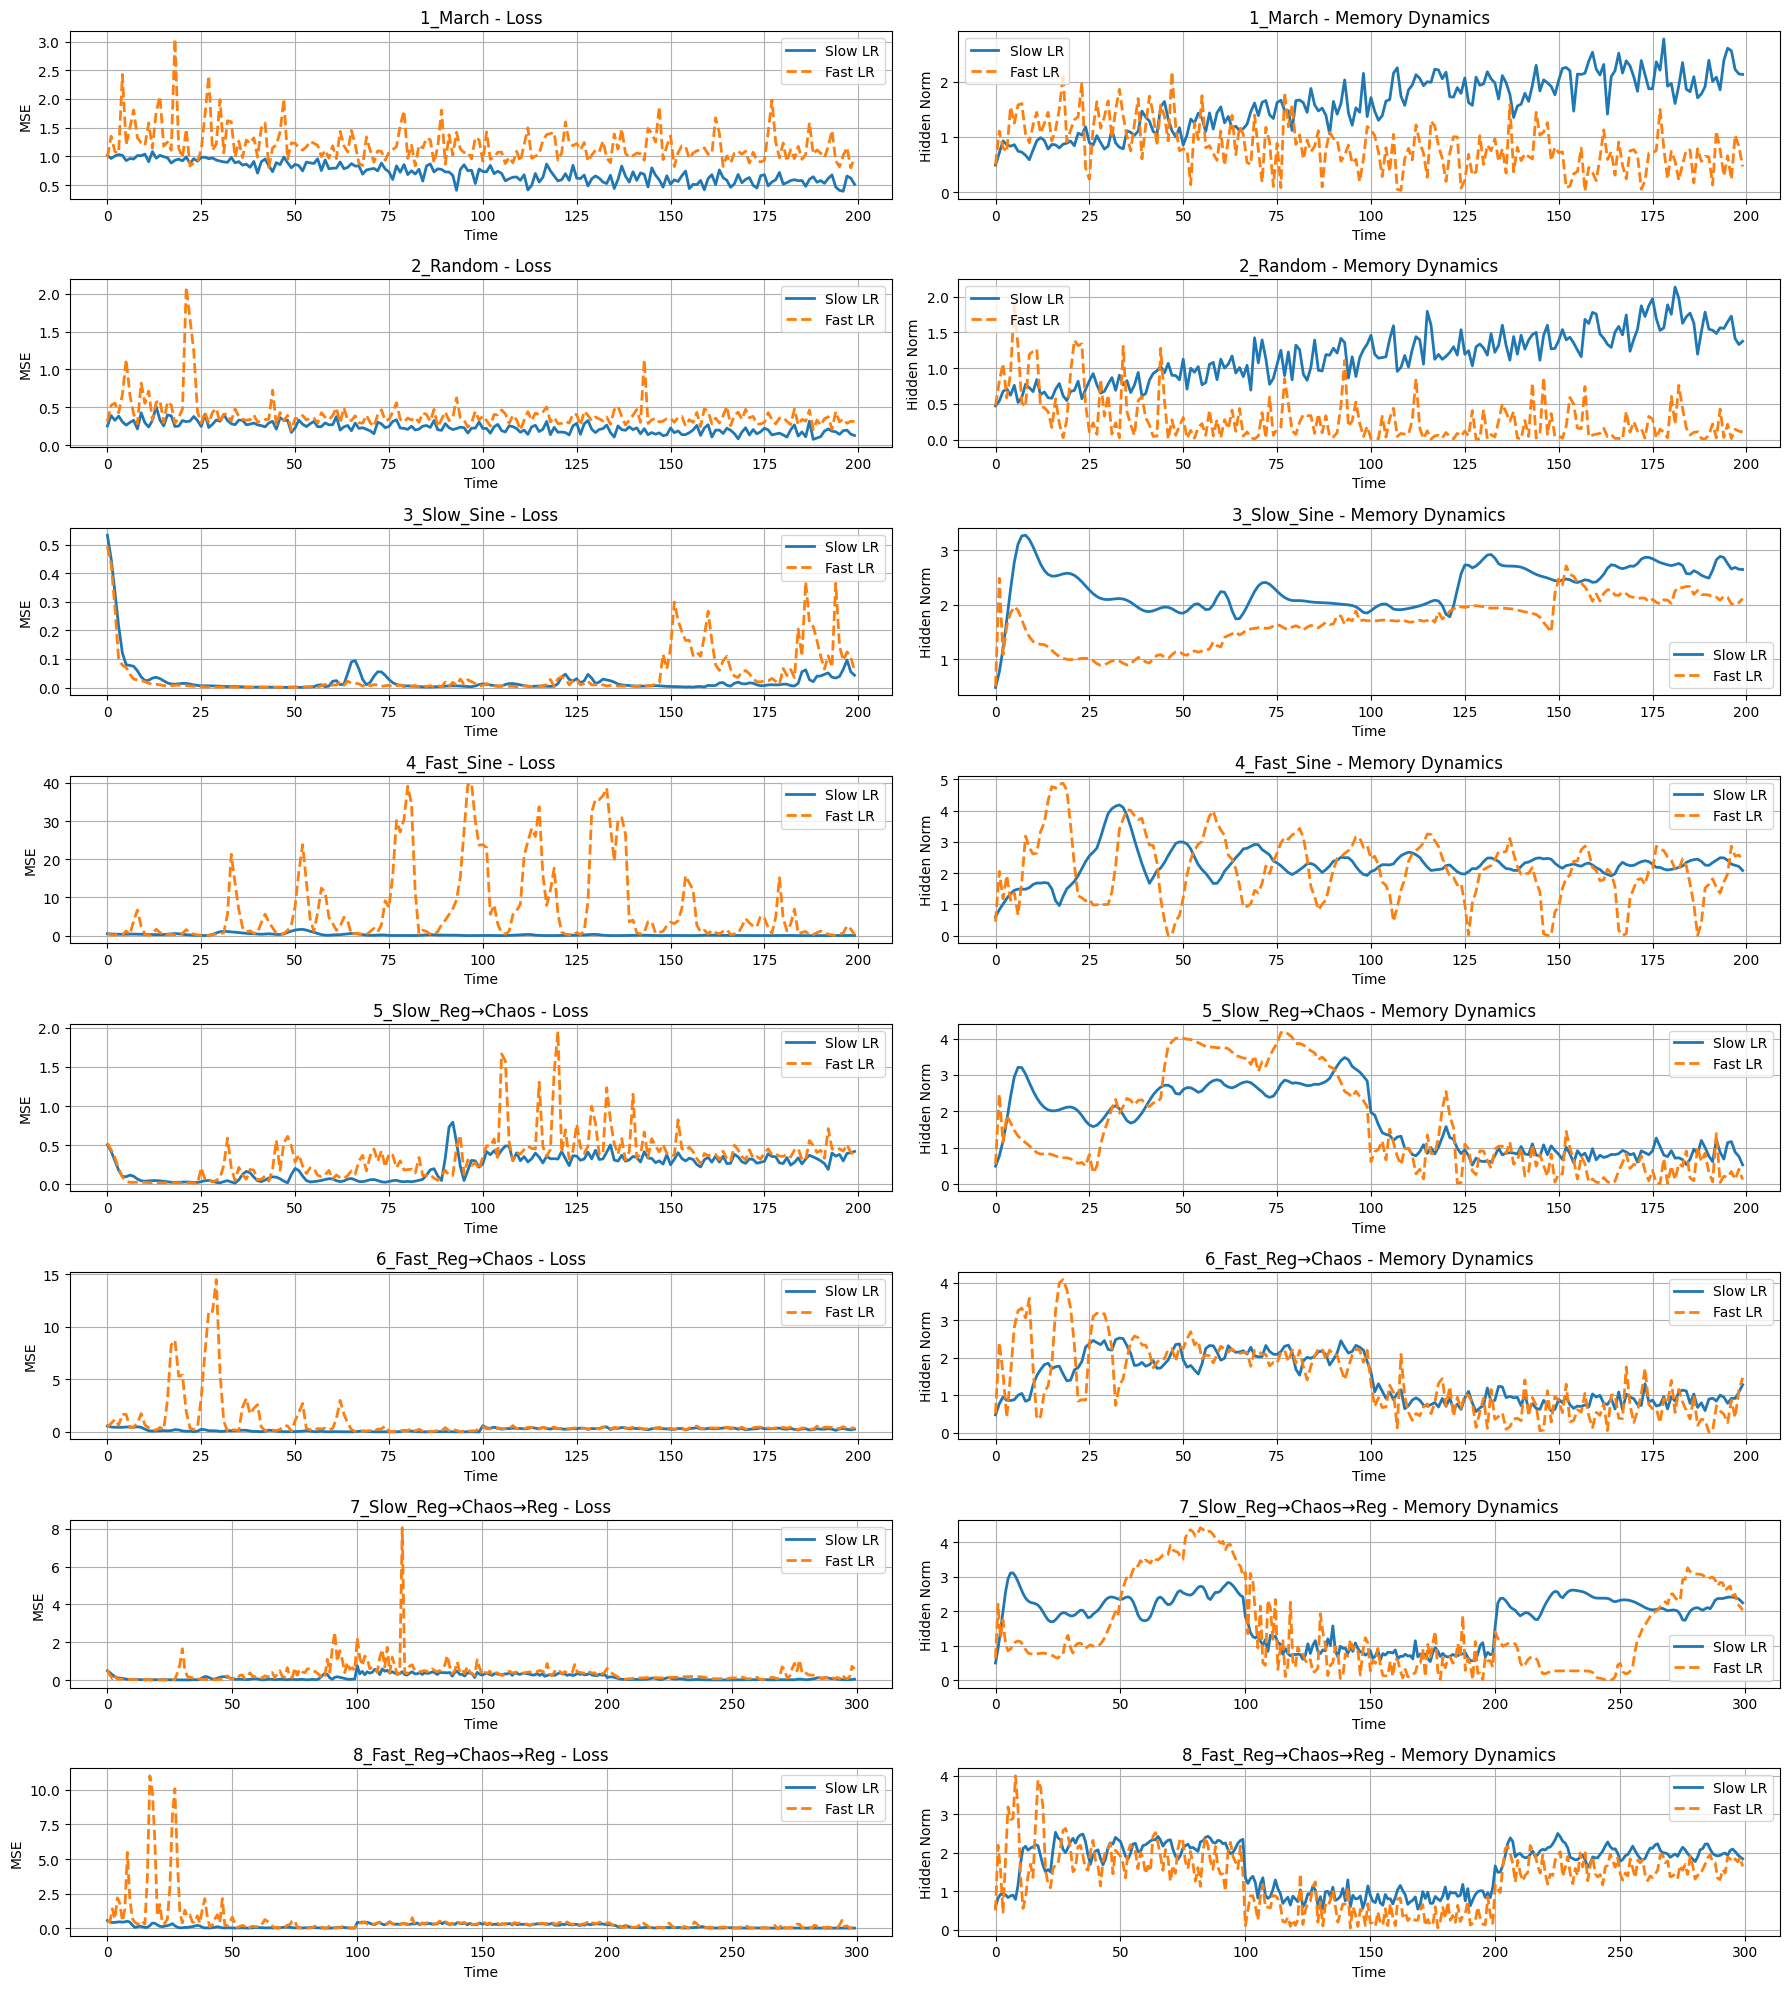

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# =========================================================
# Configuration
# =========================================================
D = 30
H = 30
LR_SLOW = 0.01
LR_FAST = 0.1
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

# =========================================================
# Organization (1 LSTM = 1 organization)
# =========================================================
class OrganizationLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim)
        self.linear = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        out = self.linear(out)
        return out, hidden

# =========================================================
# Environment Generators
# =========================================================

# 1) March-style (+1 / -1)
def env_march(T):
    return np.random.choice([-1, 1], size=(T, D)).astype(np.float32)

# 2) General random (continuous)
def env_random(T):
    return np.random.uniform(-1, 1, size=(T, D)).astype(np.float32)

# 3–4) Sinusoidal with phase shift
def env_sinusoid(T, freq):
    t = np.linspace(0, 2 * np.pi * freq, T)
    X = []
    for d in range(D):
        phase = 2 * np.pi * d / D
        X.append(np.sin(t + phase))
    return np.stack(X, axis=1).astype(np.float32)

# 5–6) Regular → Chaos
def env_reg_chaos(T1, T2, freq):
    part1 = env_sinusoid(T1, freq)
    part2 = env_random(T2)
    return np.vstack([part1, part2])

# 7–8) Regular → Chaos → Regular
def env_reg_chaos_reg(T1, T2, T3, freq):
    part1 = env_sinusoid(T1, freq)
    part2 = env_random(T2)
    part3 = env_sinusoid(T3, freq)
    return np.vstack([part1, part2, part3])

# =========================================================
# Run function
# =========================================================
def run_env(X, lr):
    T = X.shape[0]

    model = OrganizationLSTM(D, H)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    x = torch.from_numpy(X).unsqueeze(1)

    losses = []
    memory = []

    hidden = None
    for t in range(T):
        optimizer.zero_grad()

        out, hidden = model(x[t:t+1], hidden)

        # ---- critical fix ----
        hidden = (hidden[0].detach(), hidden[1].detach())

        loss = loss_fn(out.squeeze(0), x[t])
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        memory.append(hidden[0].norm().item())

    return np.array(losses), np.array(memory)

# =========================================================
# Define all scenarios
# =========================================================
scenarios = {
    "1_March": env_march(200),
    "2_Random": env_random(200),
    "3_Slow_Sine": env_sinusoid(200, freq=1),
    "4_Fast_Sine": env_sinusoid(200, freq=10),
    "5_Slow_Reg→Chaos": env_reg_chaos(100, 100, freq=1),
    "6_Fast_Reg→Chaos": env_reg_chaos(100, 100, freq=10),
    "7_Slow_Reg→Chaos→Reg": env_reg_chaos_reg(100, 100, 100, freq=1),
    "8_Fast_Reg→Chaos→Reg": env_reg_chaos_reg(100, 100, 100, freq=10),
}

# =========================================================
# Run experiments
# =========================================================
results = {}

for name, X in scenarios.items():
    print(f"Running: {name}")

    slow_loss, slow_mem = run_env(X, LR_SLOW)
    fast_loss, fast_mem = run_env(X, LR_FAST)

    results[name] = {
        "slow_loss": slow_loss,
        "slow_mem": slow_mem,
        "fast_loss": fast_loss,
        "fast_mem": fast_mem,
    }

# =========================================================
# Visualization
# =========================================================
plt.figure(figsize=(18, 20))

for i, (name, res) in enumerate(results.items()):
    # Loss
    plt.subplot(8, 2, 2*i + 1)
    plt.plot(res["slow_loss"], label="Slow LR", linewidth=2)
    plt.plot(res["fast_loss"], '--', label="Fast LR", linewidth=2)
    plt.title(f"{name} - Loss")
    plt.xlabel("Time")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)

    # Memory
    plt.subplot(8, 2, 2*i + 2)
    plt.plot(res["slow_mem"], label="Slow LR", linewidth=2)
    plt.plot(res["fast_mem"], '--', label="Fast LR", linewidth=2)
    plt.title(f"{name} - Memory Dynamics")
    plt.xlabel("Time")
    plt.ylabel("Hidden Norm")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

## More enhanced code with all scenarios described in above cell

Running 1_March
Running 2_Random
Running 3_Slow_Sine
Running 4_Fast_Sine
Running 5_Slow_RegChaos
Running 6_Fast_RegChaos
Running 7_Slow_RegChaosReg
Running 8_Fast_RegChaosReg


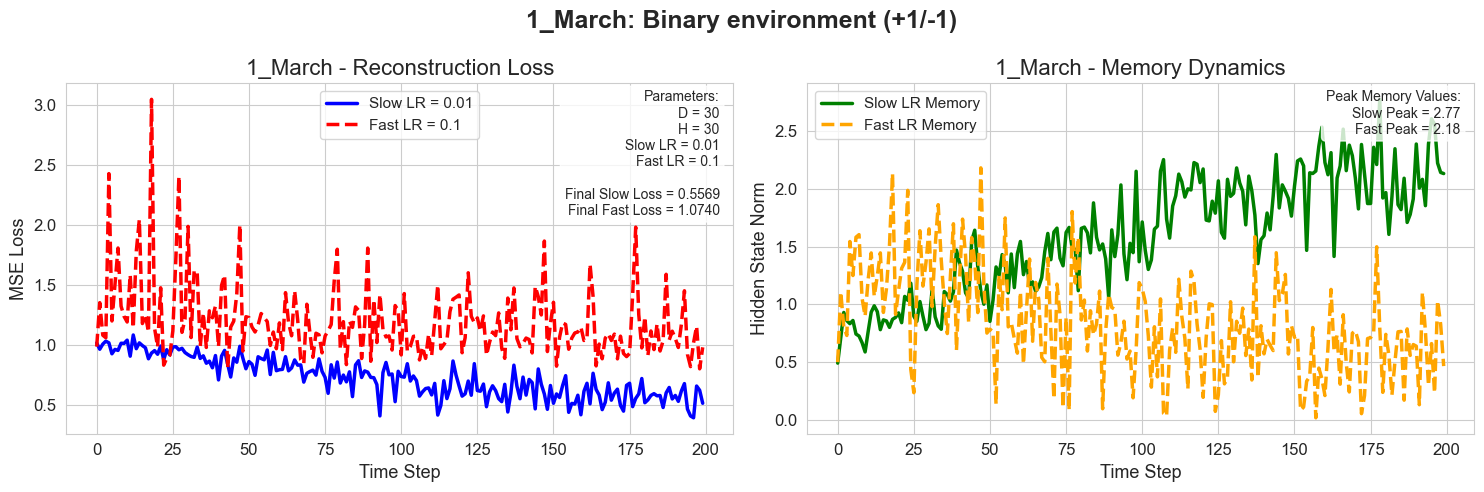

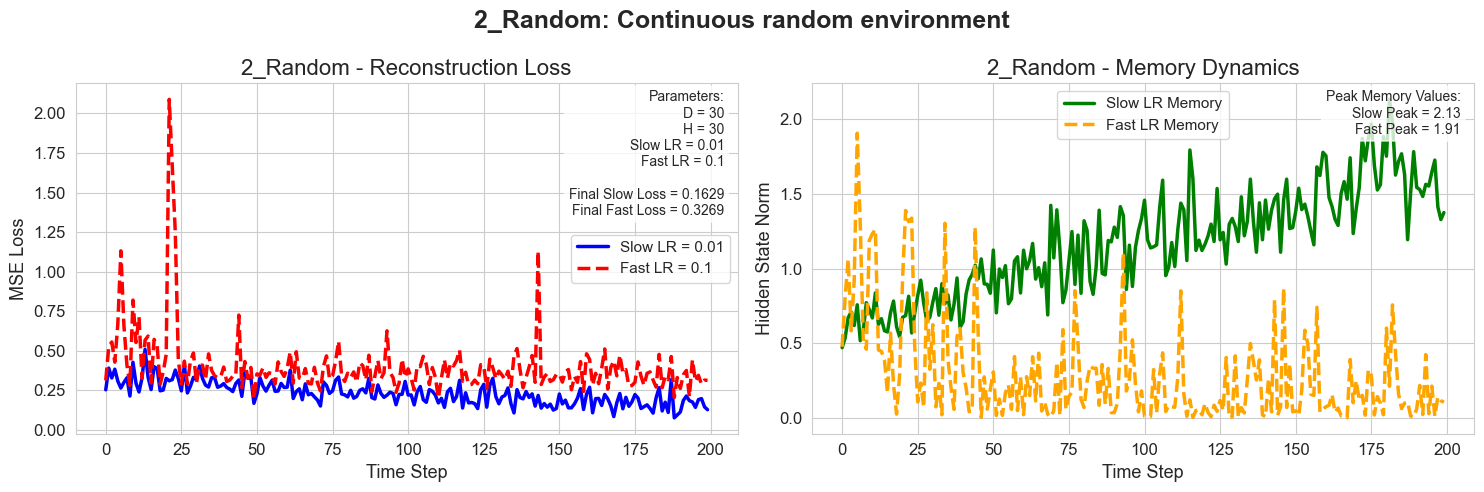

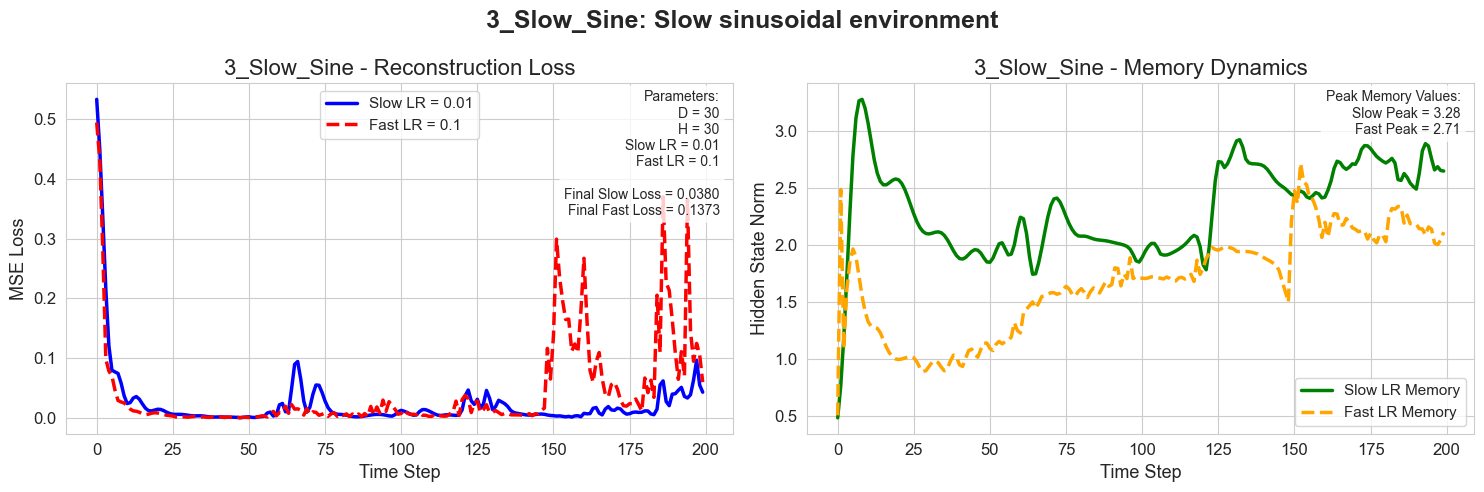

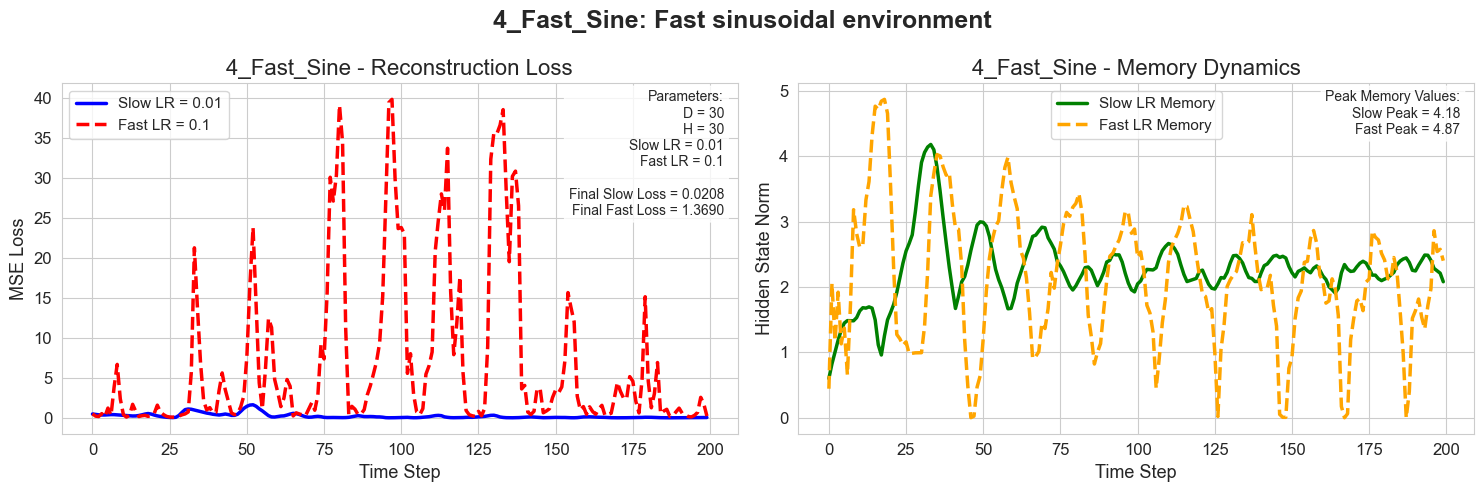

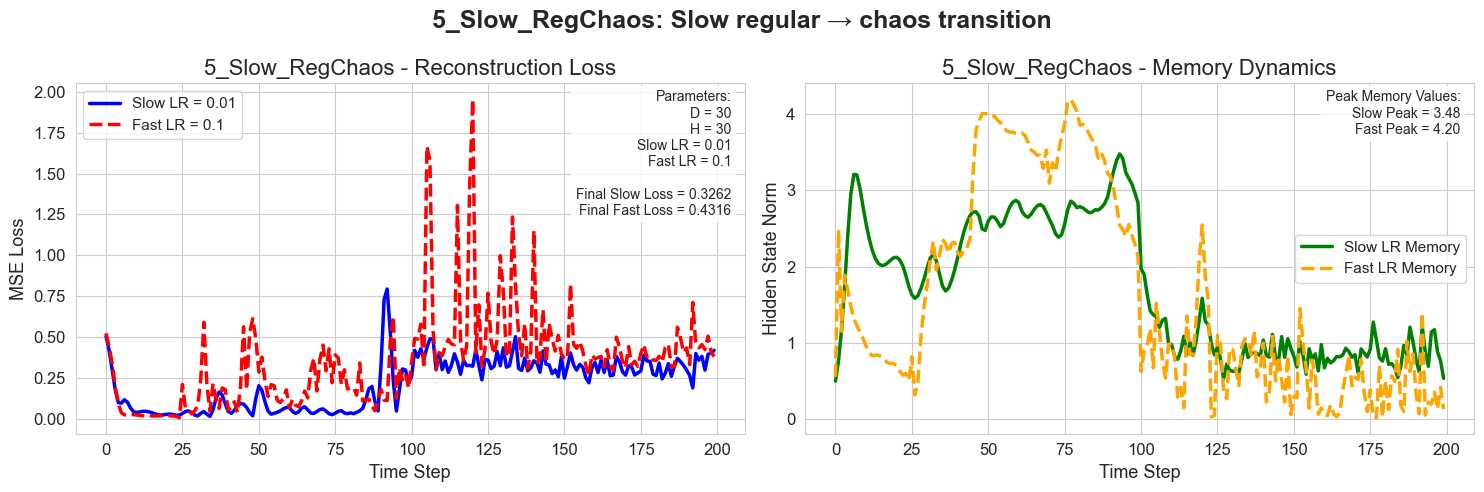

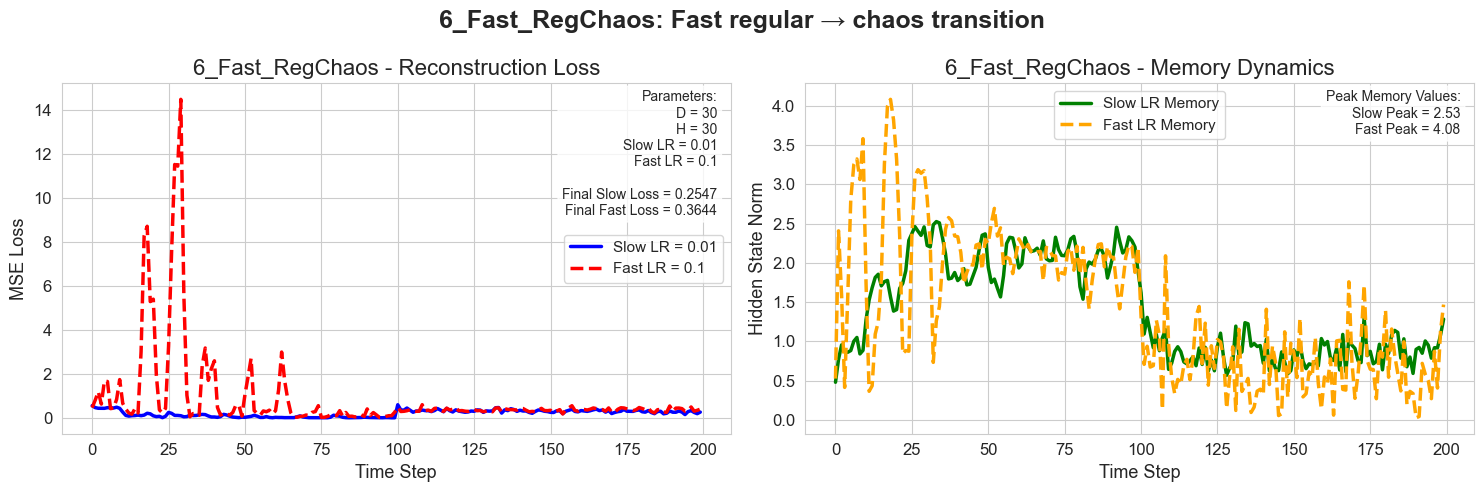

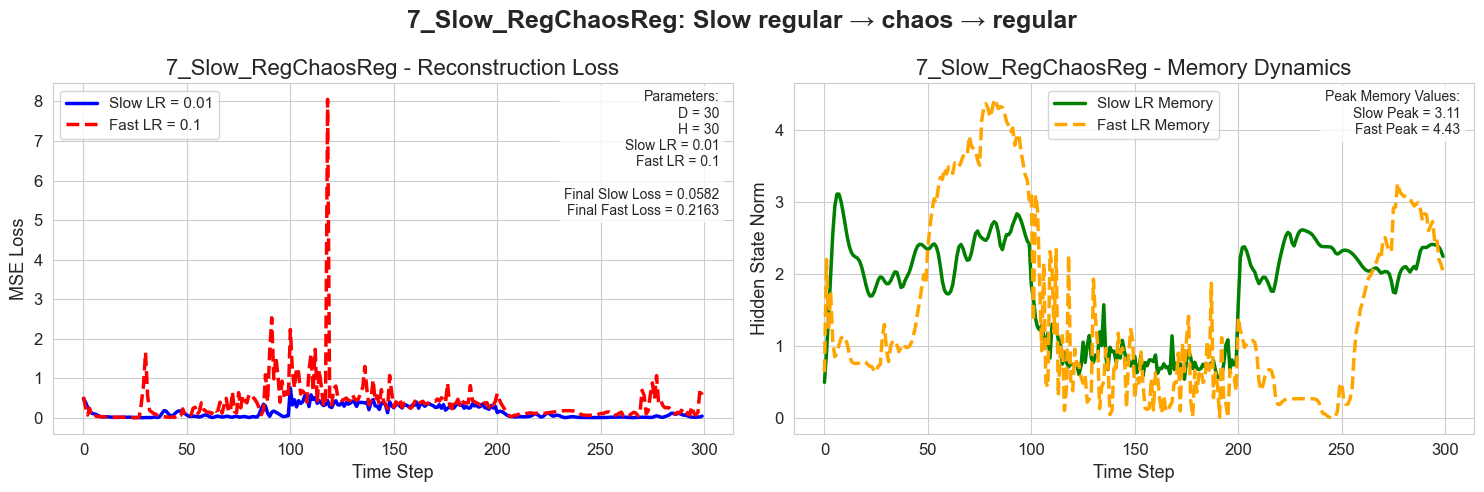

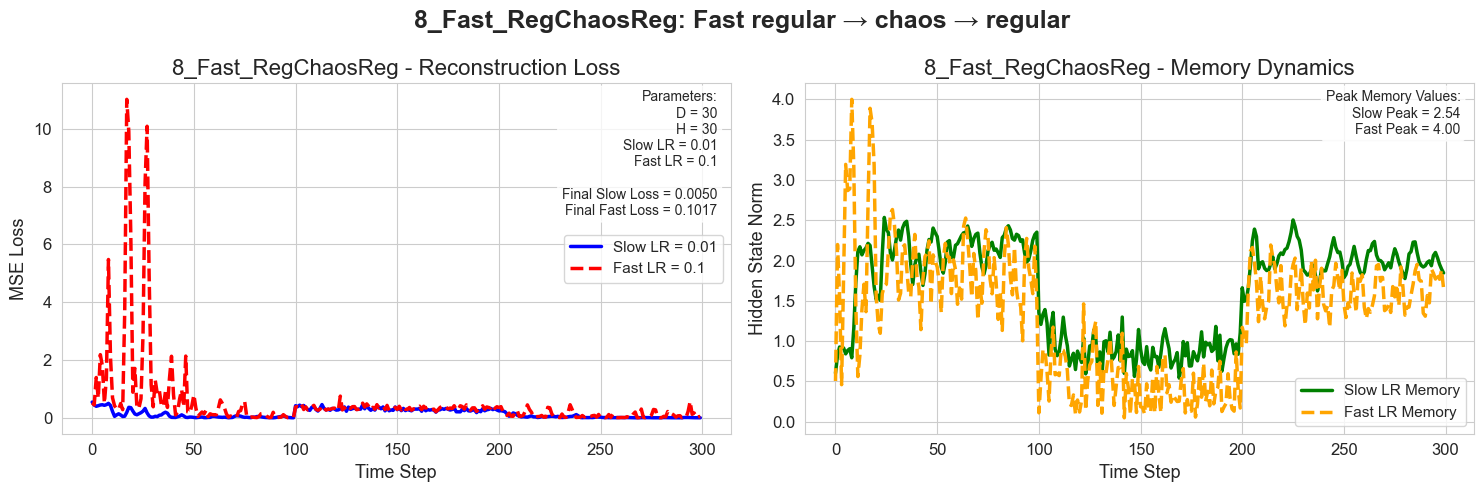

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# GLOBAL STYLE (Publication Quality)
# =========================================================
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "figure.figsize": (12, 5),
    "lines.linewidth": 2.5
})

# =========================================================
# Configuration
# =========================================================
D = 30
H = 30

LR_SLOW = 0.01
LR_FAST = 0.1

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

# =========================================================
# Organization (1 LSTM = 1 organization)
# =========================================================
class OrganizationLSTM(nn.Module):

    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        self.lstm = nn.LSTM(input_dim, hidden_dim)
        self.linear = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, hidden=None):

        out, hidden = self.lstm(x, hidden)
        out = self.linear(out)

        return out, hidden

# =========================================================
# Environment Generators
# =========================================================

# 1) March-style (+1 / -1)
def env_march(T):

    return np.random.choice(
        [-1, 1],
        size=(T, D)
    ).astype(np.float32)

# 2) General random
def env_random(T):

    return np.random.uniform(
        -1,
        1,
        size=(T, D)
    ).astype(np.float32)

# 3–4) Sinusoidal
def env_sinusoid(T, freq):

    t = np.linspace(0, 2*np.pi*freq, T)

    X = []

    for d in range(D):

        phase = 2*np.pi*d/D

        X.append(np.sin(t + phase))

    return np.stack(X, axis=1).astype(np.float32)

# 5–6) Regular → Chaos
def env_reg_chaos(T1, T2, freq):

    part1 = env_sinusoid(T1, freq)
    part2 = env_random(T2)

    return np.vstack([part1, part2])

# 7–8) Regular → Chaos → Regular
def env_reg_chaos_reg(T1, T2, T3, freq):

    part1 = env_sinusoid(T1, freq)
    part2 = env_random(T2)
    part3 = env_sinusoid(T3, freq)

    return np.vstack([part1, part2, part3])

# =========================================================
# Run function
# =========================================================
def run_env(X, lr):

    T = X.shape[0]

    model = OrganizationLSTM(D, H)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    loss_fn = nn.MSELoss()

    x = torch.from_numpy(X).unsqueeze(1)

    losses = []
    memory = []

    hidden = None

    for t in range(T):

        optimizer.zero_grad()

        out, hidden = model(x[t:t+1], hidden)

        # detach hidden state
        hidden = (
            hidden[0].detach(),
            hidden[1].detach()
        )

        loss = loss_fn(out.squeeze(0), x[t])

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

        # hidden state norm
        memory.append(
            hidden[0].norm().item()
        )

    return np.array(losses), np.array(memory)

# =========================================================
# Define scenarios
# =========================================================
scenarios = {

    "1_March": {
        "data": env_march(200),
        "description": "Binary environment (+1/-1)"
    },

    "2_Random": {
        "data": env_random(200),
        "description": "Continuous random environment"
    },

    "3_Slow_Sine": {
        "data": env_sinusoid(200, freq=1),
        "description": "Slow sinusoidal environment"
    },

    "4_Fast_Sine": {
        "data": env_sinusoid(200, freq=10),
        "description": "Fast sinusoidal environment"
    },

    "5_Slow_RegChaos": {
        "data": env_reg_chaos(100, 100, freq=1),
        "description": "Slow regular → chaos transition"
    },

    "6_Fast_RegChaos": {
        "data": env_reg_chaos(100, 100, freq=10),
        "description": "Fast regular → chaos transition"
    },

    "7_Slow_RegChaosReg": {
        "data": env_reg_chaos_reg(100, 100, 100, freq=1),
        "description": "Slow regular → chaos → regular"
    },

    "8_Fast_RegChaosReg": {
        "data": env_reg_chaos_reg(100, 100, 100, freq=10),
        "description": "Fast regular → chaos → regular"
    }
}

# =========================================================
# Run all experiments
# =========================================================
results = {}

for name, scenario in scenarios.items():

    print(f"Running {name}")

    X = scenario["data"]

    slow_loss, slow_mem = run_env(X, LR_SLOW)
    fast_loss, fast_mem = run_env(X, LR_FAST)

    results[name] = {

        "slow_loss": slow_loss,
        "fast_loss": fast_loss,

        "slow_mem": slow_mem,
        "fast_mem": fast_mem
    }

# =========================================================
# INDIVIDUAL PLOTS
# =========================================================
for name, res in results.items():

    # =====================================================
    # Compute statistics
    # =====================================================
    slow_final_loss = np.mean(res["slow_loss"][-20:])
    fast_final_loss = np.mean(res["fast_loss"][-20:])

    slow_peak_mem = np.max(res["slow_mem"])
    fast_peak_mem = np.max(res["fast_mem"])

    # =====================================================
    # Create figure
    # =====================================================
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # =====================================================
    # LOSS PLOT
    # =====================================================
    ax[0].plot(
        res["slow_loss"],
        label=f"Slow LR = {LR_SLOW}",
        color="blue"
    )

    ax[0].plot(
        res["fast_loss"],
        '--',
        label=f"Fast LR = {LR_FAST}",
        color="red"
    )

    ax[0].set_title(f"{name} - Reconstruction Loss")
    ax[0].set_xlabel("Time Step")
    ax[0].set_ylabel("MSE Loss")
    ax[0].legend()
    ax[0].grid(True)

    # Add parameter text
    text_loss = (
        f"Parameters:\n"
        f"D = {D}\n"
        f"H = {H}\n"
        f"Slow LR = {LR_SLOW}\n"
        f"Fast LR = {LR_FAST}\n\n"
        f"Final Slow Loss = {slow_final_loss:.4f}\n"
        f"Final Fast Loss = {fast_final_loss:.4f}"
    )

    ax[0].text(
        0.98,
        0.98,
        text_loss,
        transform=ax[0].transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )

    # =====================================================
    # MEMORY PLOT
    # =====================================================
    ax[1].plot(
        res["slow_mem"],
        label="Slow LR Memory",
        color="green"
    )

    ax[1].plot(
        res["fast_mem"],
        '--',
        label="Fast LR Memory",
        color="orange"
    )

    ax[1].set_title(f"{name} - Memory Dynamics")
    ax[1].set_xlabel("Time Step")
    ax[1].set_ylabel("Hidden State Norm")
    ax[1].legend()
    ax[1].grid(True)

    # Add parameter text
    text_mem = (
        f"Peak Memory Values:\n"
        f"Slow Peak = {slow_peak_mem:.2f}\n"
        f"Fast Peak = {fast_peak_mem:.2f}"
    )

    ax[1].text(
        0.98,
        0.98,
        text_mem,
        transform=ax[1].transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )

    # =====================================================
    # Main Title
    # =====================================================
    plt.suptitle(
        f"{name}: {scenarios[name]['description']}",
        fontsize=18,
        fontweight='bold'
    )

    plt.tight_layout()

    # =====================================================
    # Save Figure
    # =====================================================
    plt.savefig(
        f"{name}_publication_plot.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

### Hidden cell state analysis

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# STYLE
# =========================================================
sns.set_style("whitegrid")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "figure.figsize": (14, 10),
    "lines.linewidth": 2.5
})

# =========================================================
# CONFIGURATION
# =========================================================
D = 30          # Input dimensions
H = 30          # Hidden dimensions

T = 200         # Time steps

LR_SLOW = 0.01
LR_FAST = 0.1

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

# =========================================================
# MARCH-STYLE ENVIRONMENT
# =========================================================
def env_march(T):

    return np.random.choice(
        [-1, 1],
        size=(T, D)
    ).astype(np.float32)

# =========================================================
# LSTM ORGANIZATION
# =========================================================
class OrganizationLSTM(nn.Module):

    def __init__(self, input_dim, hidden_dim):

        super().__init__()

        self.lstm = nn.LSTM(input_dim, hidden_dim)

        self.linear = nn.Linear(
            hidden_dim,
            input_dim
        )

    def forward(self, x, hidden=None):

        out, hidden = self.lstm(x, hidden)

        out = self.linear(out)

        return out, hidden

# =========================================================
# RUN FUNCTION
# =========================================================
def run_env_with_cell_state(X, lr):

    model = OrganizationLSTM(D, H)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    loss_fn = nn.MSELoss()

    x = torch.from_numpy(X).unsqueeze(1)

    # =====================================================
    # STORAGE
    # =====================================================
    losses = []

    hidden_norms = []   # h_n
    cell_norms = []     # c_n

    hidden = None

    # =====================================================
    # TIME LOOP
    # =====================================================
    for t in range(T):

        optimizer.zero_grad()

        out, hidden = model(
            x[t:t+1],
            hidden
        )

        # =================================================
        # DETACH MEMORY
        # =================================================
        hidden = (
            hidden[0].detach(),
            hidden[1].detach()
        )

        # =================================================
        # LOSS
        # =================================================
        loss = loss_fn(
            out.squeeze(0),
            x[t]
        )

        loss.backward()

        optimizer.step()

        # =================================================
        # STORE VALUES
        # =================================================
        losses.append(loss.item())

        # Hidden state norm (h_n)
        h_norm = hidden[0].norm().item()

        # Cell state norm (c_n)
        c_norm = hidden[1].norm().item()

        hidden_norms.append(h_norm)
        cell_norms.append(c_norm)

    return (
        np.array(losses),
        np.array(hidden_norms),
        np.array(cell_norms)
    )

# =========================================================
# GENERATE SCENARIO 1
# =========================================================
X = env_march(T)

# =========================================================
# RUN SLOW LEARNING
# =========================================================
slow_loss, slow_h, slow_c = run_env_with_cell_state(
    X,
    LR_SLOW
)

# =========================================================
# RUN FAST LEARNING
# =========================================================
fast_loss, fast_h, fast_c = run_env_with_cell_state(
    X,
    LR_FAST
)

# =========================================================
# VISUALIZATION
# =========================================================
fig, ax = plt.subplots(3, 1, figsize=(14, 14))

# =========================================================
# 1. LOSS
# =========================================================
ax[0].plot(
    slow_loss,
    label=f"Slow LR = {LR_SLOW}",
    color="blue"
)

ax[0].plot(
    fast_loss,
    '--',
    label=f"Fast LR = {LR_FAST}",
    color="red"
)

ax[0].set_title(
    "Scenario 1 (March Environment) - Reconstruction Loss",
    fontsize=18,
    fontweight='bold'
)

ax[0].set_xlabel("Time Step")
ax[0].set_ylabel("MSE Loss")

ax[0].legend()
ax[0].grid(True)

# =========================================================
# 2. HIDDEN STATE h_n
# =========================================================
ax[1].plot(
    slow_h,
    label="Slow LR Hidden State",
    color="green"
)

ax[1].plot(
    fast_h,
    '--',
    label="Fast LR Hidden State",
    color="orange"
)

ax[1].set_title(
    "Hidden State Dynamics (h_n)",
    fontsize=16,
    fontweight='bold'
)

ax[1].set_xlabel("Time Step")
ax[1].set_ylabel("||h_n||")

ax[1].legend()
ax[1].grid(True)

# =========================================================
# 3. CELL STATE c_n
# =========================================================
ax[2].plot(
    slow_c,
    label="Slow LR Cell State",
    color="purple"
)

ax[2].plot(
    fast_c,
    '--',
    label="Fast LR Cell State",
    color="brown"
)

ax[2].set_title(
    "Cell State Dynamics (c_n)",
    fontsize=16,
    fontweight='bold'
)

ax[2].set_xlabel("Time Step")
ax[2].set_ylabel("||c_n||")

ax[2].legend()
ax[2].grid(True)

# =========================================================
# MAIN TITLE
# =========================================================
plt.suptitle(
    "LSTM Organizational Learning Dynamics\nScenario 1: March-Style Binary Environment",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()

# =========================================================
# SAVE FIGURE
# =========================================================
plt.savefig(
    "Scenario1_Hidden_and_Cell_State.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================================================
# PRINT SUMMARY
# =========================================================
print("\n====================================")
print("SUMMARY STATISTICS")
print("====================================")

print(f"\nSlow LR Final Loss: {slow_loss[-1]:.4f}")
print(f"Fast LR Final Loss: {fast_loss[-1]:.4f}")

print(f"\nSlow LR Final Hidden Norm: {slow_h[-1]:.4f}")
print(f"Fast LR Final Hidden Norm: {fast_h[-1]:.4f}")

print(f"\nSlow LR Final Cell Norm: {slow_c[-1]:.4f}")
print(f"Fast LR Final Cell Norm: {fast_c[-1]:.4f}")